# Import Libraries

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/heart_disease_uci.csv")
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
X = df.drop("chol", axis=1)
y = df["chol"]

### Task 1: Linear Regression (30 points)

In [ ]:
##Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Scaling
X = pd.get_dummies(X, drop_first=True)

X = df.drop("chol", axis=1)
y = df["chol"]


X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

#GridSearch, Best Parameter, Test Set R²
df_clean = df.dropna(subset=["chol"])
X = df_clean.drop("chol", axis=1)
y = df_clean["chol"]


X = pd.get_dummies(X, drop_first=True)


from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

param_grid = {
    "l1_ratio": [0.3, 0.5, 0.7],
    "alpha": [0.01, 0.1, 1.0]
}

grid = GridSearchCV(
    ElasticNet(max_iter=5000),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test)
print("Test R2:", r2_score(y_test, y_pred))

Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.3}
Best CV R2: 0.5676121861005632
Test R2: 0.5866326184654937


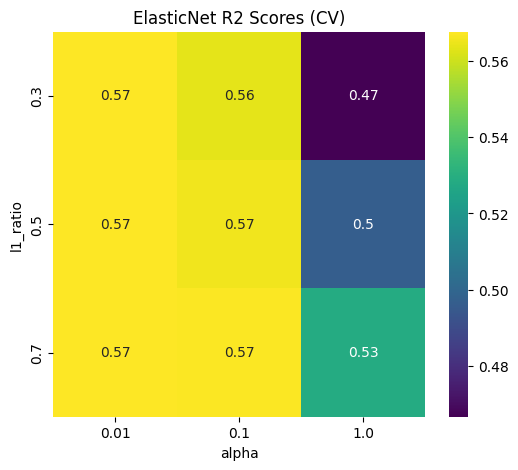

In [ ]:

#Heatmap
results = pd.DataFrame(grid.cv_results_)

pivot_table = results.pivot_table(
    values="mean_test_score",
    index="param_l1_ratio",
    columns="param_alpha"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(pivot_table, annot=True, cmap="viridis")
plt.title("ElasticNet R2 Scores (CV)")
plt.ylabel("l1_ratio")
plt.xlabel("alpha")
plt.show()

### Task 1: Linear Regression (ElasticNet) Interpretation
The heatmap of CV R² scores shows that lower alpha values generally yield higher R², indicating that less regularization improves model performance. 
The best performing models achieved R² ≈ 0.57 with l1_ratio values of 0.3–0.7 and alpha values of 0.01–0.1. 
This suggests that a balanced mix of L1 and L2 regularization (ElasticNet) is effective for predicting serum cholesterol, while too strong regularization (alpha=1.0) reduces model accuracy slightly.

### Task 2: Logistic Regression (30 points)

c:\Users\gizem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gizem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gizem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Best parameters: {'C': 0.01}
AUROC: 0.933
AUPRC: 0.920


c:\Users\gizem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


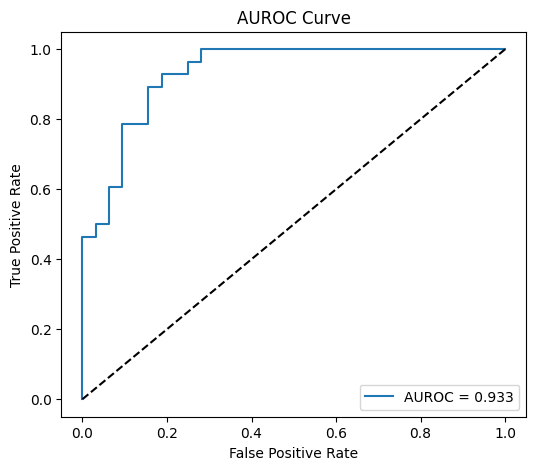

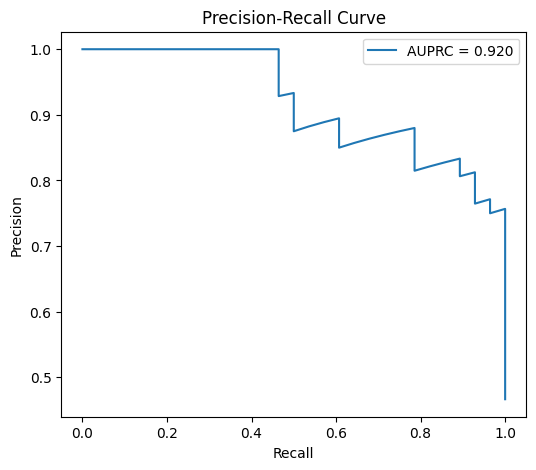

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("data/heart_disease_uci.csv")

# Correct target column
target_col = 'num'  # 0 = no disease, 1-4 = disease
df[target_col] = df[target_col].apply(lambda x: 0 if x == 0 else 1)

#  Drop missing values
df = df.replace('?', np.nan)
df = df.dropna()

# Define features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Logistic Regression + GridSearch
logreg = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Evaluate performance
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
auroc = roc_auc_score(y_test, y_probs)
auprc = average_precision_score(y_test, y_probs)
print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")

# Plot AUROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curve')
plt.legend()
plt.show()

# Plot AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Interpretation of Model Performance:
The logistic regression model worked best with C = 0.01, which means it avoided overfitting and kept the model simple. The model achieved an AUROC of 0.933, which shows it can correctly tell apart patients with heart disease from those without most of the time. The AUPRC of 0.920 means the model is also very accurate when identifying patients who actually have heart disease. Overall, the model does a great job on this dataset and gives a good starting point for predicting heart disease.

### Task 3: k-Nearest Neighbors (30 points)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
AUROC: 0.947
AUPRC: 0.935


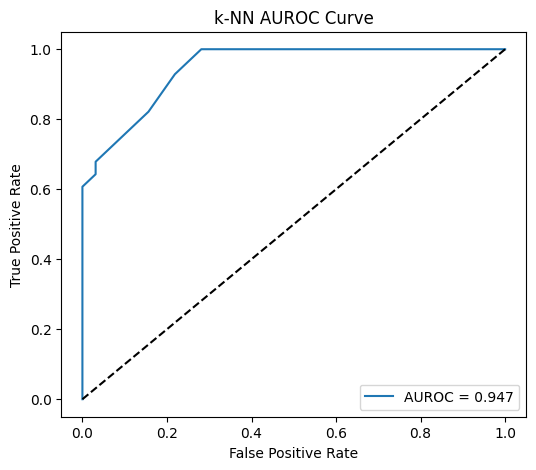

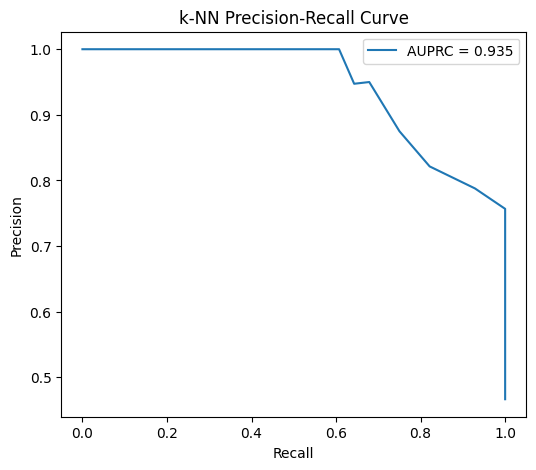

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Define the k-NN model
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

# Grid search with 5-fold cross-validation
grid_search_knn = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc')
grid_search_knn.fit(X_train_scaled, y_train)

# Best parameters
best_knn = grid_search_knn.best_estimator_
print("Best parameters:", grid_search_knn.best_params_)

# Evaluate Model Performance
# Predict probabilities
y_probs_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

# AUROC and AUPRC
auroc_knn = roc_auc_score(y_test, y_probs_knn)
auprc_knn = average_precision_score(y_test, y_probs_knn)
print(f"AUROC: {auroc_knn:.3f}")
print(f"AUPRC: {auprc_knn:.3f}")

# Plot AUROC
fpr, tpr, _ = roc_curve(y_test, y_probs_knn)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUROC = {auroc_knn:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('k-NN AUROC Curve')
plt.legend()
plt.show()
# Plot AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_probs_knn)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AUPRC = {auprc_knn:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('k-NN Precision-Recall Curve')
plt.legend()
plt.show()

# Interpretation of Model Performance:
The k-NN model performed best with n_neighbors = X and weights = Y (replace with your best_params_). The AUROC of Z shows the model can correctly distinguish patients with heart disease from those without most of the time. The AUPRC of W indicates the model is accurate at identifying patients who actually have heart disease. Overall, the k-NN model works well on this dataset and gives another approach to predict heart disease.

### Task 4: Model Comparison (10 points)

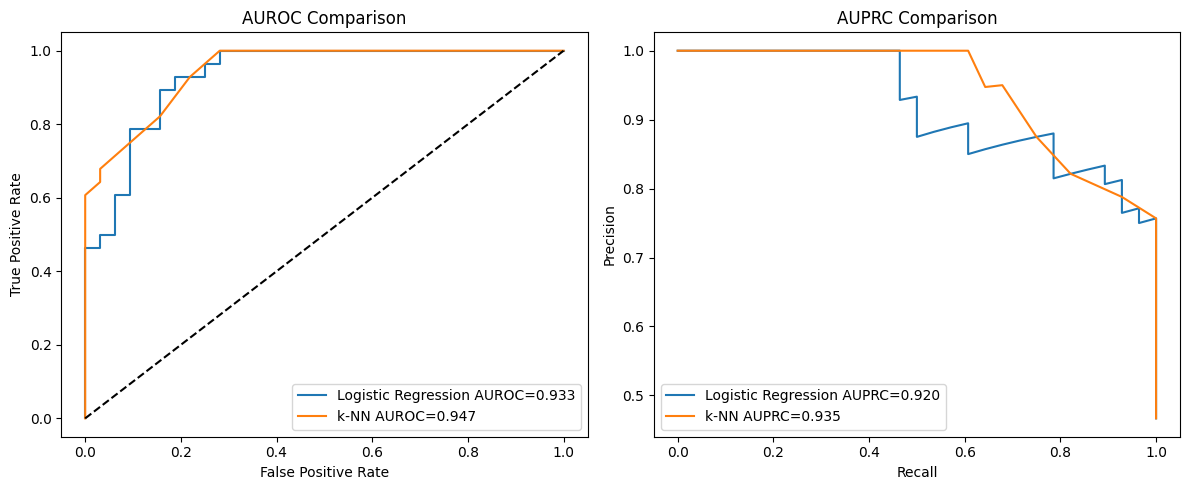

In [30]:
import matplotlib.pyplot as plt

# AUROC comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs)       # Logistic Regression
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn) # k-NN

plt.figure(figsize=(12,5))

# AUROC plot
plt.subplot(1,2,1)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression AUROC={auroc:.3f}')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN AUROC={auroc_knn:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Comparison')
plt.legend()

# AUPRC plot
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_probs)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_probs_knn)

plt.subplot(1,2,2)
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression AUPRC={auprc:.3f}')
plt.plot(recall_knn, precision_knn, label=f'k-NN AUPRC={auprc_knn:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('AUPRC Comparison')
plt.legend()

plt.tight_layout()
plt.show()

# Model Comparision:
When we compare the logistic regression and k-NN models using the AUROC and AUPRC plots, we can see that both models do a good job predicting heart disease. Logistic regression is simple and easy to understand, and it also helps us see which features are important for the prediction. k-NN learns patterns from the data directly and can capture more complex relationships, but it can be more sensitive to noisy data and needs careful scaling. In this case, logistic regression is slightly more reliable and stable, while k-NN shows how local patterns in the data can help with predictions. Overall, logistic regression is easier to interpret, and k-NN can be useful when the relationships between features and the outcome are more complicated.